**miniproject1--Detect only specific objects**

In [ ]:
#opencv,ultradetect libraries

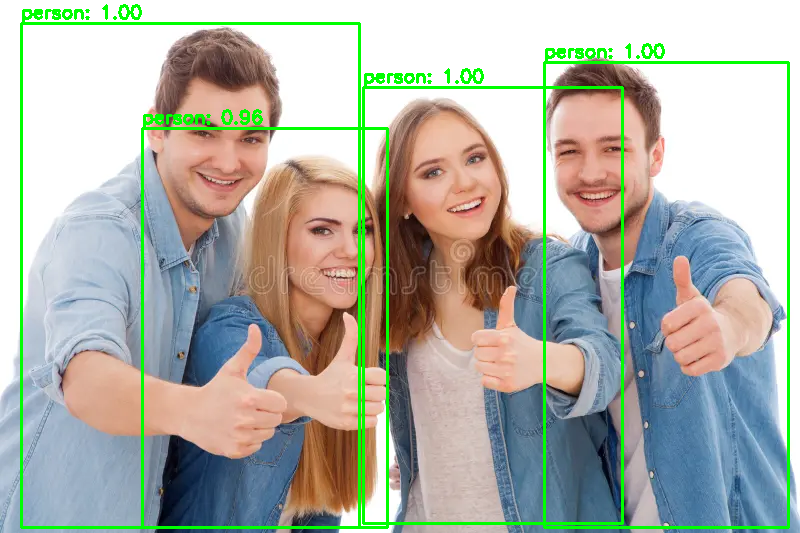

Number of people detected: 4


In [ ]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import cv2
from google.colab.patches import cv2_imshow # Import for displaying images in Colab

# ------------------------------
# Load model with updated API
# ------------------------------
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

# Load COCO labels
labels = weights.meta["categories"]

# ------------------------------
# Load image
# ------------------------------
img_path = "/content/group-happy-young-people-isolated-white-background-52734245.webp"   # Using the original image path
image = cv2.imread(img_path)
orig = image.copy()

# Convert to RGB and tensor
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
tensor = F.to_tensor(image_rgb)
tensor = tensor.unsqueeze(0)

# ------------------------------
# Run detection
# ------------------------------
with torch.no_grad():
    predictions = model(tensor)

boxes = predictions[0]["boxes"]
scores = predictions[0]["scores"]
classes = predictions[0]["labels"]

# ------------------------------
# Draw boxes and count people
# ------------------------------
person_count = 0
for box, score, cls in zip(boxes, scores, classes):
    if score < 0.8:  # Lowered confidence threshold to 0.6
        continue

    # Get the label name
    label_name = labels[cls]

    x1, y1, x2, y2 = box.int().tolist()
    label = f"{label_name}: {score:.2f}"

    cv2.rectangle(orig, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    if label_name == "person":
        person_count += 1

# ------------------------------
# Show result and print count
# ------------------------------
cv2_imshow(orig)
cv2.waitKey(0)
cv2.destroyAllWindows()

print(f"Number of people detected: {person_count}")

**week5**

stemming and lemmatisation

In [ ]:
# NLP
# stemming and lemmatization are both text normalization techniques in NLP that reduce words to a common root form, but they differ in their approach and accuracy. Stemming is a faster, rule-based process that chops off word endings, which may result in a non-dictionary word. Lemmatization is a more sophisticated, context-aware process that uses a dictionary to find the base or dictionary form of a word (lemma), resulting in a valid word.
# nltk---natural language tool kit
# application---whereas in search engine appear suggestions based on the related words,wordscorrection in texteditors

In [ ]:
#lemmatization
#import modules
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')
lemmatizer=WordNetLemmatizer() #object creation
print("----Lemmatization---")
print("rocks:",lemmatizer.lemmatize("rocks"))
print("better:",lemmatizer.lemmatize("better",pos="a")) #a denotes adjective in 'pos'
print("corpora",lemmatizer.lemmatize("corpora"))


----Lemmatization---
rocks: rock
better: good
corpora corpus


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:

#stemming
from nltk.stem import PorterStemmer
porter_stemmer=PorterStemmer()#create a instance

words=['running','jumps','happily','running','happily']#example words

stemmed_words=[porter_stemmer.stem(word) for word in words]#apply steeming to each word
print("----stemming---")
print("original words:",words)
print("stemmed words:",stemmed_words)

----stemming---
original words: ['running', 'jumps', 'happily', 'running', 'happily']
stemmed words: ['run', 'jump', 'happili', 'run', 'happili']


In [ ]:
#stemming in the words of text file with 10 words
from nltk import PorterStemmer
porter_stemmer=PorterStemmer()
#read words from a text file
with open("/content/info_eg.txt") as file:
  text=file.read()
words=text.split()
stemmed_words=[porter_stemmer.stem(word) for word in words]
print("original words:-",words)
print("stemmed words:--",stemmed_words)


original words:- ['enjoyingly', 'excited', 'birthday', 'beautiful', 'faster', 'works', 'eating', 'dancing', 'forecasts']
stemmed words:-- ['enjoyingli', 'excit', 'birthday', 'beauti', 'faster', 'work', 'eat', 'danc', 'forecast']


10/12/2025---Chatbot

In [ ]:
#Greeting example with condition statements
print("Chatbot:Hi! I am Your chatbot.Type 'bye'to exit.")
while True:
  user=input("You:")
  if user.lower()=="hi":
    print("Chatbot: Hello! How can I help you?")
  elif user.lower()=='hey watsapp':
    print("Its a beautiful day.Yeah tell me how about you!")
  elif user.lower()=="bye":
    print("Chatbot:Yeah!!Great Time with You.. Have a Great day")
    break
  else:
    print("sorry I don't understand")


Chatbot:Hi! I am Your chatbot.Type 'bye'to exit.
You:Hi
Chatbot: Hello! How can I help you?
You:hey watsapp
sorry I don't understand
You:bye
Chatbot:Yeah!!Great Time with You.. Have a Great day


In [ ]:
class Chatbot:
  def __init__(self):
    #Group questions that we should have to ask
    self.responses={
        "My name is ChatBot!!":[
            "what is your name",
            "what's your name",
            "who are you",
            "tell me your name",
            "your name please"
        ],
        "I am doing great! Thank You":[
            "how are you",
            "hey watsapp",
            "how do you feel",
            "are you ok?!",
            "how its going"
        ],
        "I'm a chatbot created to help you!":[
            "what are you",
            "what do you do",
            "what is your purpose",
            "why do you exist"
        ]
    }
  def get_response(self,user_input):
    user_input=user_input.lower().strip()

    #check each answer's associated questions
    for answer,questions in self.responses.items():
      if any(question in user_input for question in questions):
        return answer
    return "I'm not sure how to answer that."

#usage
bot=Chatbot()
print(bot.get_response("What's your name?"))
print(bot.get_response("hey watsapp"))
print(bot.get_response("what do you do"))

My name is ChatBot!!
I am doing great! Thank You
I'm a chatbot created to help you!
